<a href="https://colab.research.google.com/github/eduardmendoza92/DataMining/blob/main/Caso_Practico_Aplicado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import numpy as np

In [3]:
url = "https://raw.githubusercontent.com/eduardmendoza92/DataMining/refs/heads/main/Archivos/Prestige_modificado.csv"

In [4]:
df = pd.read_csv(url, sep=';')
print("Dataset Cargado Correctamente")

Dataset Cargado Correctamente


In [5]:
print(df.shape)

(102, 7)


In [20]:
print(df.head())

            occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1


In [21]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB
None


In [22]:
print(df.isnull().sum())

occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64


In [23]:
print(df.duplicated().sum())

0


In [26]:
print(df.describe().round(2))

       education    income   women  prestige   census  type_num
count     102.00    102.00  102.00    102.00   102.00    102.00
mean       10.74   6797.90   28.98     46.83  5401.77      1.84
std         2.73   4245.92   31.72     17.20  2644.99      0.82
min         6.38    611.00    0.00     14.80  1113.00      0.00
25%         8.44   4106.00    3.59     35.22  3120.50      1.00
50%        10.54   5930.50   13.60     43.60  5135.00      2.00
75%        12.65   8187.25   52.20     59.28  8312.50      2.00
max        15.97  25879.00   97.51     87.20  9517.00      3.00


In [28]:
# Filtramos para quedarnos solo con las columnas que tienen números
variables_numericas = df.select_dtypes(include=['int64', 'float64'])

# Calculamos la matriz de correlación (Coeficiente de Pearson)
matriz_correlacion = variables_numericas.corr()

# Mostramos la matriz completa redondeada para que sea legible
print(matriz_correlacion.round(3))

# Extraemos la columna de Prestige y la ordenamos de forma descendente
relacion_prestigio = matriz_correlacion['prestige'].sort_values(ascending=False)

print(relacion_prestigio.round(3))


           education  income  women  prestige  census  type_num
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000
prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


In [31]:
plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

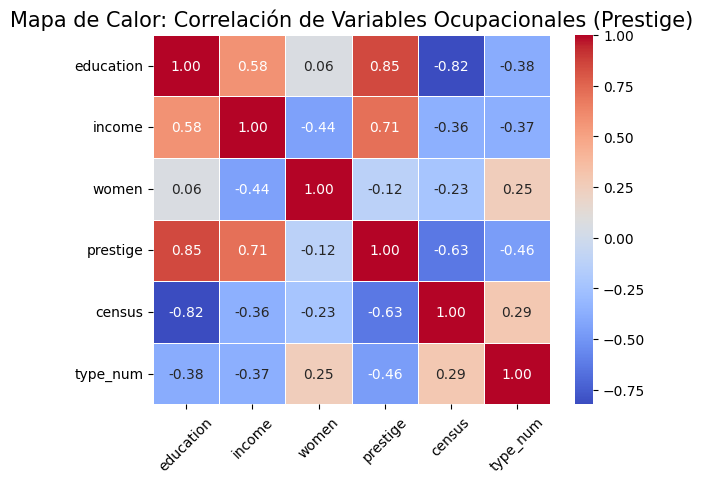

In [35]:
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor: Correlación de Variables Ocupacionales (Prestige)", fontsize=15)
plt.xticks(rotation=45) # Inclina los nombres de abajo para que se lean mejor
plt.yticks(rotation=0)
plt.show()

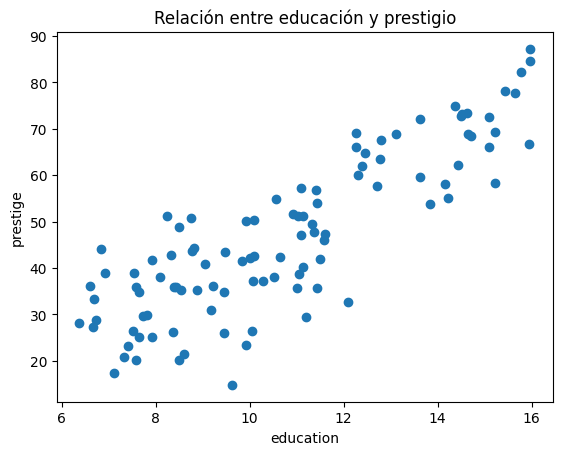

In [ ]:
plt.figure()
plt.scatter(df['education'], df['prestige'])
plt.xlabel('education')
plt.ylabel('prestige')
plt.title('Relación entre educación y prestigio')
plt.show()

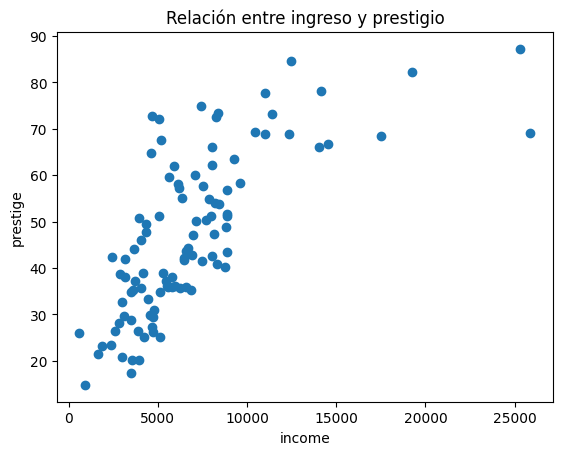

In [ ]:
plt.figure()
plt.scatter(df['income'], df['prestige'])
plt.xlabel('income')
plt.ylabel('prestige')
plt.title('Relación entre ingreso y prestigio')
plt.show()


/tmp/ipykernel_6615/3811110220.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tipo_Ocupacion', y='prestige', data=df_plot, palette='Set2')


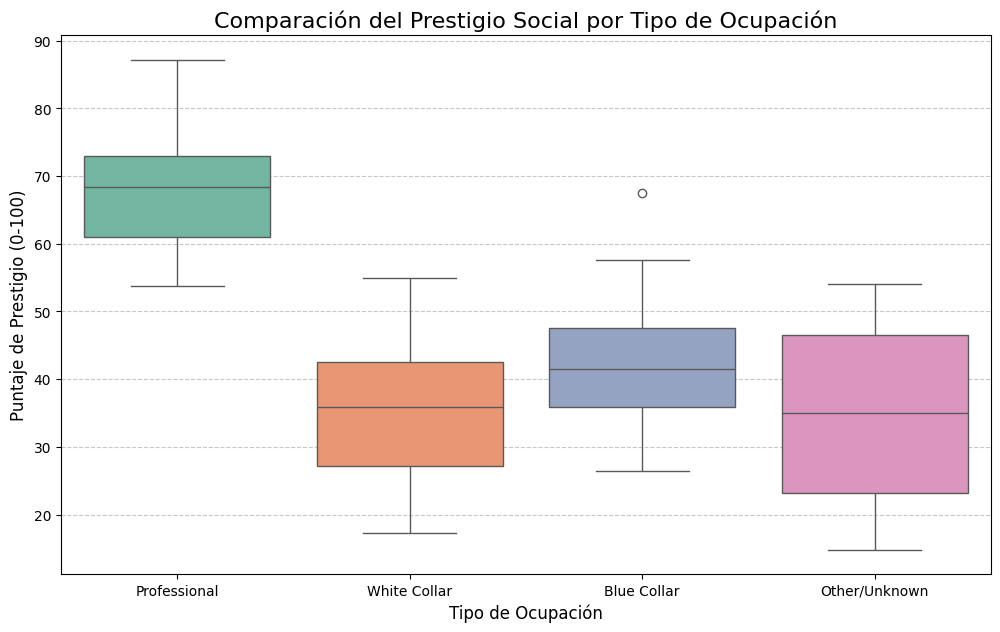

In [37]:
df_plot = df.copy()

mapa_tipos = {1: 'Professional', 2: 'White Collar', 3: 'Blue Collar', 0: 'Other/Unknown'}
df_plot['Tipo_Ocupacion'] = df_plot['type_num'].map(mapa_tipos)

plt.figure(figsize=(12, 7))

sns.boxplot(x='Tipo_Ocupacion', y='prestige', data=df_plot, palette='Set2')

plt.title('Comparación del Prestigio Social por Tipo de Ocupación', fontsize=16)
plt.xlabel('Tipo de Ocupación', fontsize=12)
plt.ylabel('Puntaje de Prestigio (0-100)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))


           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00
